In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure Group,Charge Level,Multiple Lines,Tech Support,Internet Service,Online Security,Contract,Churn
0,0,0,0,0,1,0,0,0
1,1,1,0,0,1,1,1,0
2,0,1,0,0,1,1,0,1
3,2,1,0,1,1,1,1,0
4,0,2,0,0,2,0,0,1


Churn
0    5163
1    1869
Name: count, dtype: int64


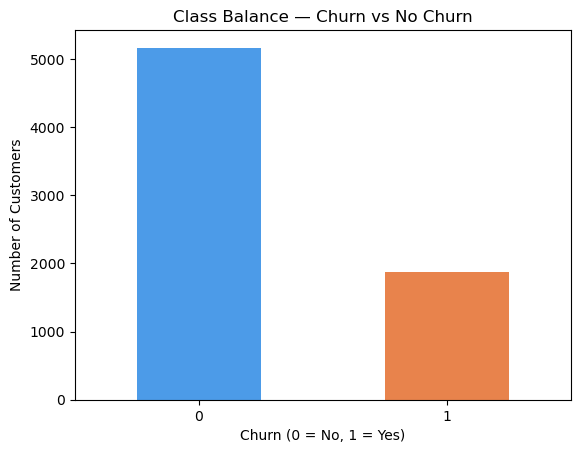

In [3]:
# 1. CLASS BALANCE — how many customers churned vs stayed?
print(df_model["Churn"].value_counts())

df_model["Churn"].value_counts().plot(kind="bar", color=["#4C9BE8", "#E8834C"])
plt.title("Class Balance — Churn vs No Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Tenure Group
0    47.678161
1    25.538793
2    11.929357
Name: Churn, dtype: float64


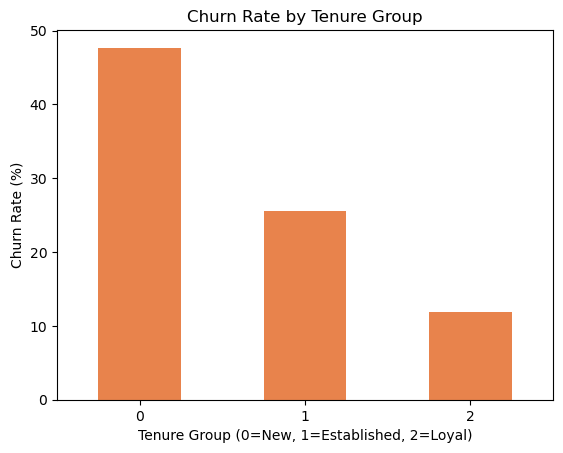

In [4]:
# 2. CHURN RATE BY TENURE GROUP
# 0 = New, 1 = Established, 2 = Loyal
churn_by_tenure = df_model.groupby("Tenure Group")["Churn"].mean() * 100
print(churn_by_tenure)

churn_by_tenure.plot(kind="bar", color="#E8834C")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (0=New, 1=Established, 2=Loyal)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Charge Level
0    10.898551
1    23.690338
2    35.497353
Name: Churn, dtype: float64


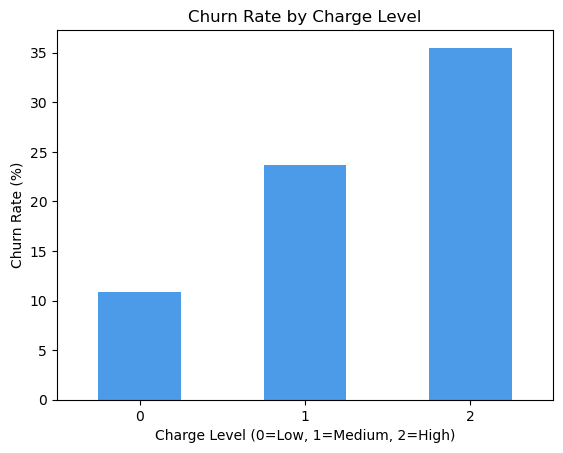

In [5]:
# 3. CHURN RATE BY CHARGE LEVEL
# 0 = Low, 1 = Medium, 2 = High
churn_by_charge = df_model.groupby("Charge Level")["Churn"].mean() * 100
print(churn_by_charge)

churn_by_charge.plot(kind="bar", color="#4C9BE8")
plt.title("Churn Rate by Charge Level")
plt.xlabel("Charge Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Multiple Lines
0    25.067651
1    28.648466
Name: Churn, dtype: float64


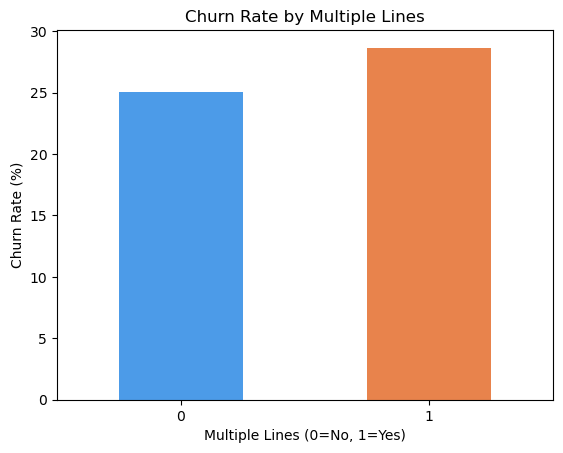

In [6]:
# 4. CHURN RATE BY MULTIPLE LINES
# 0 = No / No Phone Service, 1 = Yes
churn_by_lines = df_model.groupby("Multiple Lines")["Churn"].mean() * 100
print(churn_by_lines)

churn_by_lines.plot(kind="bar", color=["#4C9BE8", "#E8834C"])
plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines (0=No, 1=Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Tech Support
0    31.223713
1    15.203531
Name: Churn, dtype: float64


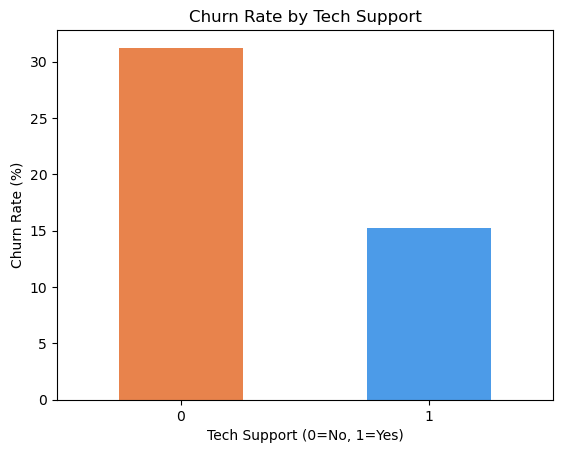

In [7]:
# 5. CHURN RATE BY TECH SUPPORT
churn_by_tech = df_model.groupby("Tech Support")["Churn"].mean() * 100
print(churn_by_tech)
churn_by_tech.plot(kind="bar", color=["#E8834C", "#4C9BE8"])
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support (0=No, 1=Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Internet Service
0     7.434211
1    18.998344
2    41.892765
Name: Churn, dtype: float64


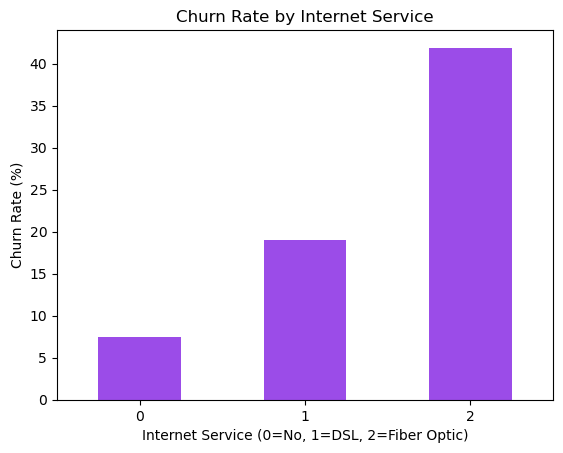

In [8]:
# 6. CHURN RATE BY INTERNET SERVICE
churn_by_internet = df_model.groupby("Internet Service")["Churn"].mean() * 100
print(churn_by_internet)
churn_by_internet.plot(kind="bar", color="#9B4CE8")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service (0=No, 1=DSL, 2=Fiber Optic)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Online Security
0    31.373331
1    14.640199
Name: Churn, dtype: float64


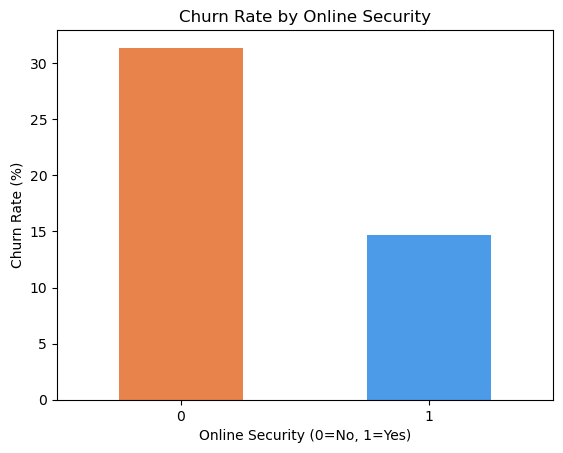

In [9]:
# 7. CHURN RATE BY ONLINE SECURITY
churn_by_security = df_model.groupby("Online Security")["Churn"].mean() * 100
print(churn_by_security)
churn_by_security.plot(kind="bar", color=["#E8834C", "#4C9BE8"])
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security (0=No, 1=Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Contract
0    42.709677
1    11.277174
2     2.848665
Name: Churn, dtype: float64


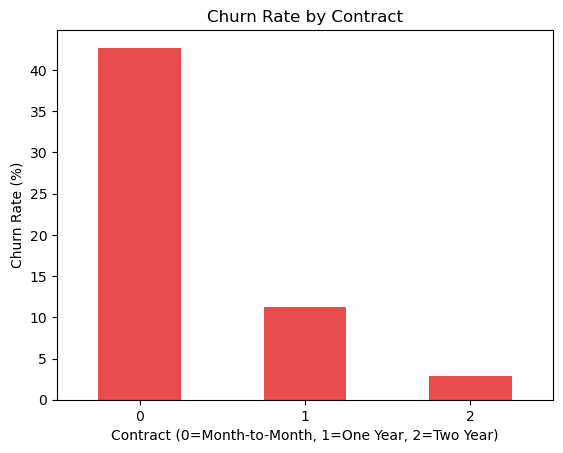

In [10]:
# 8. CHURN RATE BY CONTRACT
churn_by_contract = df_model.groupby("Contract")["Churn"].mean() * 100
print(churn_by_contract)
churn_by_contract.plot(kind="bar", color="#E84C4C")
plt.title("Churn Rate by Contract")
plt.xlabel("Contract (0=Month-to-Month, 1=One Year, 2=Two Year)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [11]:
# 9. SUMMARY TABLE
for col, label in [
    ("Tenure Group", ["New", "Established", "Loyal"]),
    ("Charge Level", ["Low", "Medium", "High"]),
    ("Tech Support", ["No", "Yes"]),
    ("Internet Service", ["No", "DSL", "Fiber Optic"]),
    ("Online Security", ["No", "Yes"]),
    ("Contract", ["Month-to-Month", "One Year", "Two Year"])
]:
    summary = df_model.groupby(col)["Churn"].agg(["count", "sum", "mean"])
    summary.columns = ["Total", "Churned", "Churn Rate"]
    summary["Churn Rate"] = (summary["Churn Rate"] * 100).round(1)
    summary.index = label
    print(f"\nChurn by {col}:")
    print(summary)


Churn by Tenure Group:
             Total  Churned  Churn Rate
New           2175     1037        47.7
Established   1856      474        25.5
Loyal         3001      358        11.9

Churn by Charge Level:
        Total  Churned  Churn Rate
Low      1725      188        10.9
Medium   1718      407        23.7
High     3589     1274        35.5

Churn by Tech Support:
     Total  Churned  Churn Rate
No    4993     1559        31.2
Yes   2039      310        15.2

Churn by Internet Service:
             Total  Churned  Churn Rate
No            1520      113         7.4
DSL           2416      459        19.0
Fiber Optic   3096     1297        41.9

Churn by Online Security:
     Total  Churned  Churn Rate
No    5017     1574        31.4
Yes   2015      295        14.6

Churn by Contract:
                Total  Churned  Churn Rate
Month-to-Month   3875     1655        42.7
One Year         1472      166        11.3
Two Year         1685       48         2.8
